# ```thinst``` tests

In [1]:
from thinst.core import *
from thinst.plots import *

In [2]:
import numpy as np
import pandas as pd

In [3]:
%matplotlib widget

In [4]:
sample_size = 20  # set sample size

x_min, x_max = 0, 100000  # set spatial limits (x axis)
y_min, y_max = 0, 100000  # set spatial limits (y axis)
z_min, z_max = pd.to_datetime('2020-01-01 00:00:00'), pd.to_datetime('2022-12-31 23:59:59')  # set temporal limits (z axis)

random_xs = np.random.uniform(x_min, x_max, size=sample_size)  # generate random x coordinates
random_ys = np.random.uniform(y_min, y_max, size=sample_size)  # generate random y coordinates
random_xys = [(x, y) for x, y in zip(random_xs, random_ys)]  # combine random x and y coordinates
random_zs = [pd.to_datetime(int(r), unit='s') for r in np.random.uniform(low=z_min.timestamp(), high=z_max.timestamp(), size=sample_size)]  # generate random datetimes (i.e., Z values)

samples = pd.DataFrame({'c': random_xys, 'd': random_zs})  # DataFrame of the random points
samples = samples.sort_values('d').reset_index(drop=True)  # sort by datetime


### Spatial

#### get_coords()

In [5]:
coords = get_coords(df=samples, coords='c')

In [6]:
check_all = []
for xya, xyb in zip(samples['c'], coords):
    check = True if xya[0] == xyb[0] and xya[1] == xyb[1] else False
    check_all.append(check)
    print(xya[0], '\t', xyb[0], '\t', xya[1], '\t', xyb[1], '\t', check)
print(f'Check all: {all(check_all)}')

63883.724313144456 	 63883.724313144456 	 7089.953415398331 	 7089.953415398331 	 True
91215.32529938743 	 91215.32529938743 	 97623.66999718835 	 97623.66999718835 	 True
83700.39845944673 	 83700.39845944673 	 68996.36717617154 	 68996.36717617154 	 True
99847.50548626593 	 99847.50548626593 	 90887.04243662259 	 90887.04243662259 	 True
80149.99895506515 	 80149.99895506515 	 94866.38986990668 	 94866.38986990668 	 True
9965.836140473282 	 9965.836140473282 	 63110.6245465958 	 63110.6245465958 	 True
33655.69899099017 	 33655.69899099017 	 47409.763256908474 	 47409.763256908474 	 True
22584.0564443077 	 22584.0564443077 	 76027.95670210838 	 76027.95670210838 	 True
33177.5455284457 	 33177.5455284457 	 43146.989114769705 	 43146.989114769705 	 True
24477.589226806827 	 24477.589226806827 	 61717.87193893646 	 61717.87193893646 	 True
6288.04635250747 	 6288.04635250747 	 16366.198685651134 	 16366.198685651134 	 True
33746.868668190575 	 33746.868668190575 	 43648.498332802534 	 

#### get_xs_ys()

In [7]:
xs, ys = get_xs_ys(coords)

In [8]:
check_all = []
for xya, xb, yb in zip(samples['c'], xs, ys):
    check = True if xya[0] == xb and xya[1] == yb else False
    check_all.append(check)
    print(xya[0], '\t', xb, '\t', xya[1], '\t', yb, '\t', check)
print(f'Check all: {all(check_all)}')

63883.724313144456 	 63883.724313144456 	 7089.953415398331 	 7089.953415398331 	 True
91215.32529938743 	 91215.32529938743 	 97623.66999718835 	 97623.66999718835 	 True
83700.39845944673 	 83700.39845944673 	 68996.36717617154 	 68996.36717617154 	 True
99847.50548626593 	 99847.50548626593 	 90887.04243662259 	 90887.04243662259 	 True
80149.99895506515 	 80149.99895506515 	 94866.38986990668 	 94866.38986990668 	 True
9965.836140473282 	 9965.836140473282 	 63110.6245465958 	 63110.6245465958 	 True
33655.69899099017 	 33655.69899099017 	 47409.763256908474 	 47409.763256908474 	 True
22584.0564443077 	 22584.0564443077 	 76027.95670210838 	 76027.95670210838 	 True
33177.5455284457 	 33177.5455284457 	 43146.989114769705 	 43146.989114769705 	 True
24477.589226806827 	 24477.589226806827 	 61717.87193893646 	 61717.87193893646 	 True
6288.04635250747 	 6288.04635250747 	 16366.198685651134 	 16366.198685651134 	 True
33746.868668190575 	 33746.868668190575 	 43648.498332802534 	 

#### get_sp_pairs()

In [9]:
spt = 10000

In [10]:
pairs = get_sp_pairs(coords=coords, sp_threshold=spt)

In [11]:
in_pairs = np.unique(np.array(pairs).flatten())
in_pairs[:5]

array([ 2,  3,  6,  8, 11])

Plot only points that are within the threshold of at least one other (all should overlap at least one other).

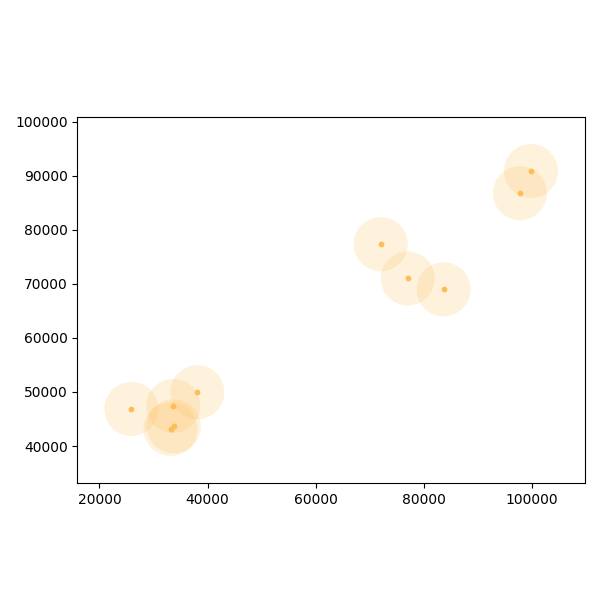

In [12]:
plot_sp(df=samples[samples.index.isin(in_pairs)], coords='c', sp_threshold=spt, colour='#fdbe57')

Plot only points that are _not_ within the threshold of at least one other (none should overlap).

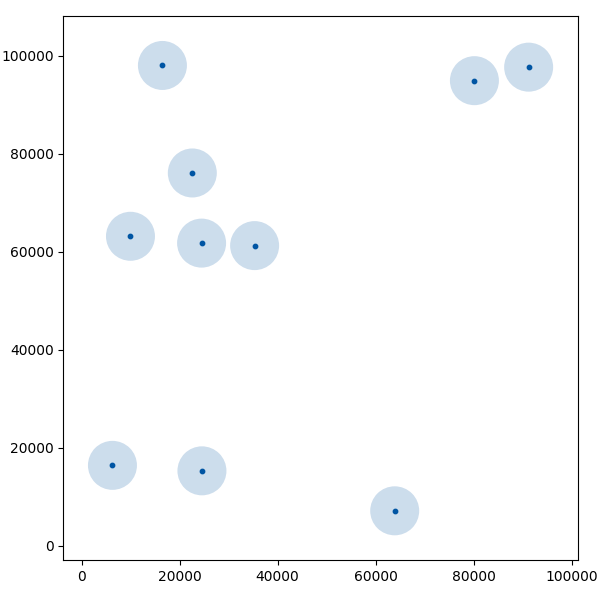

In [13]:
plot_sp(df=samples[~samples.index.isin(in_pairs)], coords='c', sp_threshold=spt, colour='#0055a3')

### Temporal

#### get_datetimes()

In [14]:
datetimes = get_datetimes(df=samples, datetimes='d')

In [15]:
check_all = []
for da, db in zip(samples['d'], datetimes):
    check = True if da == db else False
    check_all.append(check)
    print(da, '\t', db, '\t', check)
print(f'Check all: {all(check_all)}')

2020-02-12 13:36:07 	 2020-02-12 13:36:07 	 True
2020-05-19 18:21:16 	 2020-05-19 18:21:16 	 True
2020-07-16 02:06:34 	 2020-07-16 02:06:34 	 True
2020-07-27 14:16:34 	 2020-07-27 14:16:34 	 True
2020-10-06 08:42:48 	 2020-10-06 08:42:48 	 True
2020-12-10 19:36:07 	 2020-12-10 19:36:07 	 True
2021-01-31 20:22:24 	 2021-01-31 20:22:24 	 True
2021-02-28 23:47:04 	 2021-02-28 23:47:04 	 True
2021-04-21 06:37:52 	 2021-04-21 06:37:52 	 True
2021-04-26 05:18:25 	 2021-04-26 05:18:25 	 True
2021-06-06 08:20:10 	 2021-06-06 08:20:10 	 True
2021-08-05 11:53:27 	 2021-08-05 11:53:27 	 True
2022-01-04 14:56:15 	 2022-01-04 14:56:15 	 True
2022-01-10 10:03:01 	 2022-01-10 10:03:01 	 True
2022-03-16 19:35:05 	 2022-03-16 19:35:05 	 True
2022-03-22 15:32:43 	 2022-03-22 15:32:43 	 True
2022-04-01 07:47:54 	 2022-04-01 07:47:54 	 True
2022-10-10 20:09:48 	 2022-10-10 20:09:48 	 True
2022-10-25 01:17:18 	 2022-10-25 01:17:18 	 True
2022-11-13 04:20:25 	 2022-11-13 04:20:25 	 True
Check all: True


#### get_zs()

In [16]:
tmu = 'day'

In [17]:
zs = get_zs(datetimes=datetimes, tm_unit=tmu)

In [18]:
for za, zb in zip(samples['d'], zs):
    print(za, '\t', zb)

2020-02-12 13:36:07 	 18304
2020-05-19 18:21:16 	 18401
2020-07-16 02:06:34 	 18459
2020-07-27 14:16:34 	 18470
2020-10-06 08:42:48 	 18541
2020-12-10 19:36:07 	 18606
2021-01-31 20:22:24 	 18658
2021-02-28 23:47:04 	 18686
2021-04-21 06:37:52 	 18738
2021-04-26 05:18:25 	 18743
2021-06-06 08:20:10 	 18784
2021-08-05 11:53:27 	 18844
2022-01-04 14:56:15 	 18996
2022-01-10 10:03:01 	 19002
2022-03-16 19:35:05 	 19067
2022-03-22 15:32:43 	 19073
2022-04-01 07:47:54 	 19083
2022-10-10 20:09:48 	 19275
2022-10-25 01:17:18 	 19290
2022-11-13 04:20:25 	 19309


#### get_tm_pairs()
Using sample points.

In [19]:
tmt = 30
tmu = 'day'

In [20]:
pairs = get_tm_pairs(datetimes=datetimes, tm_threshold=tmt, tm_unit=tmu)

In [21]:
in_pairs = np.unique(np.array(pairs).flatten())
in_pairs

array([ 2,  3,  6,  7,  8,  9, 12, 13, 14, 15, 16, 17, 18, 19])

Plot only points that are within the threshold of at least one other (all should overlap at least one other; note that lines that end/begin at the same point count as overlapping).

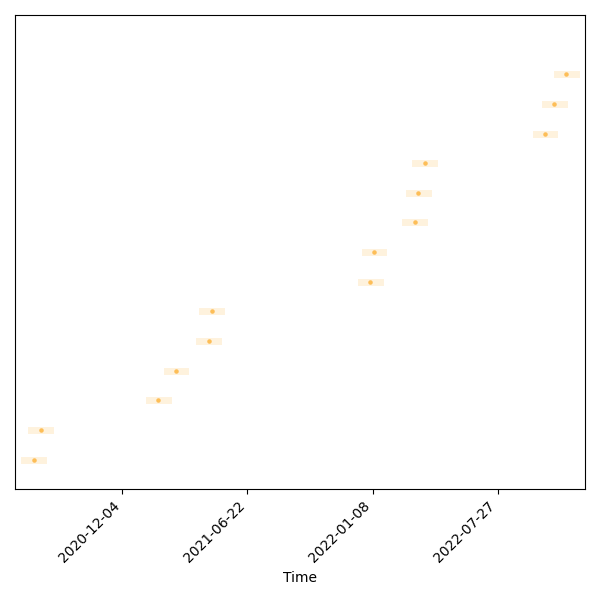

In [22]:
plot_tm(df=samples[samples.index.isin(in_pairs)], datetimes='d', tm_threshold=tmt, tm_unit=tmu, colour='#fdbe57')

Plot only points that are _not_ within the threshold of at least one other (none should overlap).

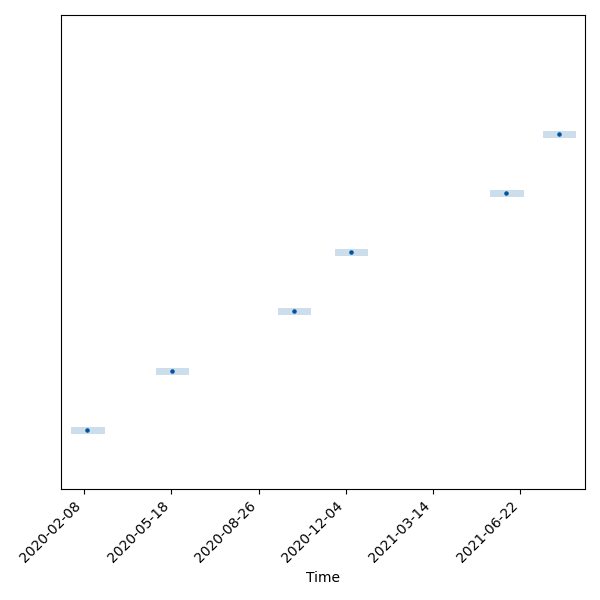

In [23]:
plot_tm(df=samples[~samples.index.isin(in_pairs)], datetimes='d', tm_threshold=tmt, tm_unit=tmu, colour='#0055a3')

#### get_tm_pairs()
Using consecutive points.

In [24]:
spt = 5000
tmt = 5
tmu = 'day'

In [25]:
from datetime import date, timedelta
datetimes_consec = [pd.to_datetime('2025-01-01') + timedelta(days=i) for i in range(1, 21)]
datetimes_consec[:5]

[Timestamp('2025-01-02 00:00:00'),
 Timestamp('2025-01-03 00:00:00'),
 Timestamp('2025-01-04 00:00:00'),
 Timestamp('2025-01-05 00:00:00'),
 Timestamp('2025-01-06 00:00:00')]

In [26]:
pairs = get_tm_pairs(datetimes=datetimes_consec, tm_threshold=tmt, tm_unit=tmu)
pairs.sort()
pairs[:5]

[(0, 1), (0, 2), (0, 3), (0, 4), (0, 5)]

In [27]:
for pair in pairs:
    diff = abs(datetimes_consec[pair[0]] - datetimes_consec[pair[1]])
    print(datetimes_consec[pair[0]], '\t', datetimes_consec[pair[1]], '\t', diff)

2025-01-02 00:00:00 	 2025-01-03 00:00:00 	 1 days 00:00:00
2025-01-02 00:00:00 	 2025-01-04 00:00:00 	 2 days 00:00:00
2025-01-02 00:00:00 	 2025-01-05 00:00:00 	 3 days 00:00:00
2025-01-02 00:00:00 	 2025-01-06 00:00:00 	 4 days 00:00:00
2025-01-02 00:00:00 	 2025-01-07 00:00:00 	 5 days 00:00:00
2025-01-03 00:00:00 	 2025-01-04 00:00:00 	 1 days 00:00:00
2025-01-03 00:00:00 	 2025-01-05 00:00:00 	 2 days 00:00:00
2025-01-03 00:00:00 	 2025-01-06 00:00:00 	 3 days 00:00:00
2025-01-03 00:00:00 	 2025-01-07 00:00:00 	 4 days 00:00:00
2025-01-03 00:00:00 	 2025-01-08 00:00:00 	 5 days 00:00:00
2025-01-04 00:00:00 	 2025-01-05 00:00:00 	 1 days 00:00:00
2025-01-04 00:00:00 	 2025-01-06 00:00:00 	 2 days 00:00:00
2025-01-04 00:00:00 	 2025-01-07 00:00:00 	 3 days 00:00:00
2025-01-04 00:00:00 	 2025-01-08 00:00:00 	 4 days 00:00:00
2025-01-04 00:00:00 	 2025-01-09 00:00:00 	 5 days 00:00:00
2025-01-05 00:00:00 	 2025-01-06 00:00:00 	 1 days 00:00:00
2025-01-05 00:00:00 	 2025-01-07 00:00:0

### Spatiotemporal

In [28]:
spt = 10000
tmt = 180
tmu = 'day'

In [29]:
coords = get_coords(df=samples, coords='c')
datetimes = get_datetimes(df=samples, datetimes='d')
pairs = get_sptm_pairs(coords=coords, sp_threshold=spt, datetimes=datetimes, tm_threshold=tmt, tm_unit=tmu)

In [30]:
in_pairs = np.unique(np.array(pairs).flatten())
in_pairs

array([ 6,  8, 11, 12, 13])

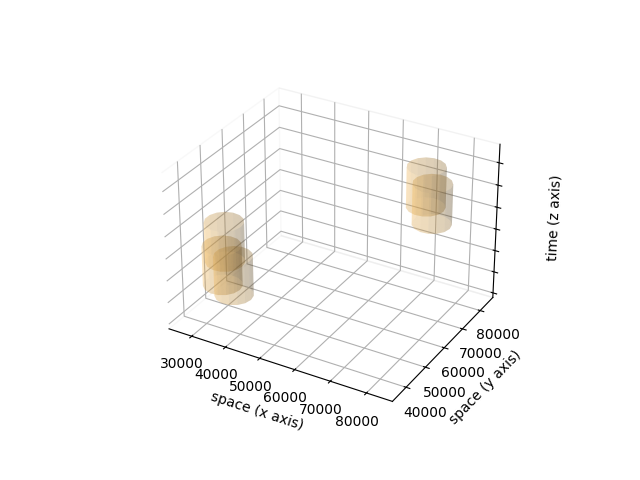

In [31]:
plot_sptm(df=samples[samples.index.isin(in_pairs)], coords='c', sp_threshold=spt, datetimes='d', tm_threshold=tmt, tm_unit=tmu, colour='#fdbe57')

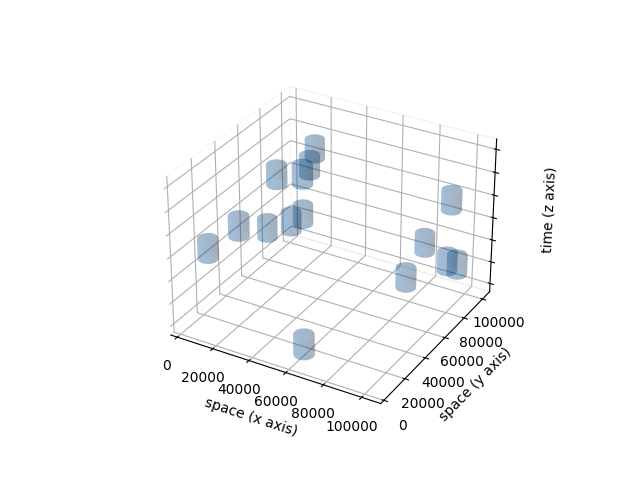

In [32]:
plot_sptm(df=samples[~samples.index.isin(in_pairs)], coords='c', sp_threshold=spt, datetimes='d', tm_threshold=tmt, tm_unit=tmu, colour='#0055a3')

### Blocks

In [33]:
spt = 10000
tmt = 60
tmu = 'day'

In [34]:
samples['year'] = samples['d'].dt.year
samples[:5]

,c,d,year
0,"(63883.724313144456, 7089.953415398331)",2020-02-12 13:36:07,2020
1,"(91215.32529938743, 97623.66999718835)",2020-05-19 18:21:16,2020
2,"(83700.39845944673, 68996.36717617154)",2020-07-16 02:06:34,2020
3,"(99847.50548626593, 90887.04243662259)",2020-07-27 14:16:34,2020
4,"(80149.99895506515, 94866.38986990668)",2020-10-06 08:42:48,2020


#### Spatial

In [35]:
thinned = thinst(
    df=samples,
    coords='c',
    sp_threshold=spt,
    block='year')

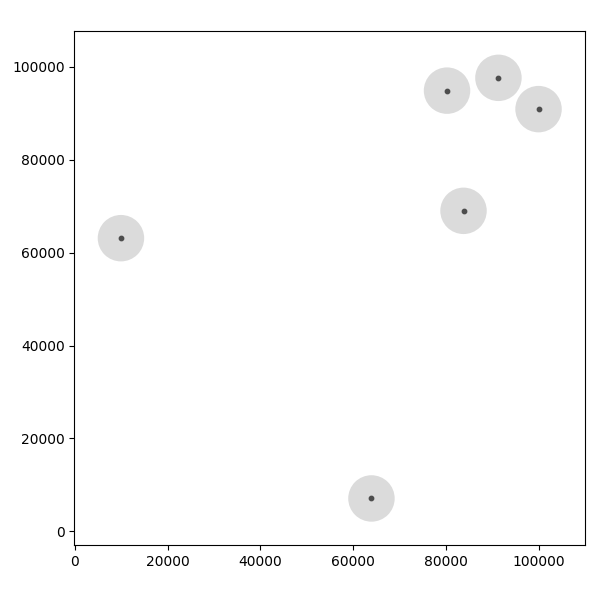

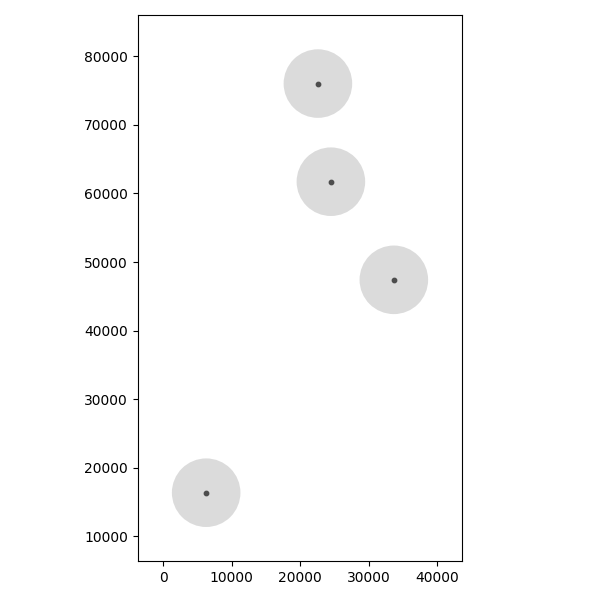

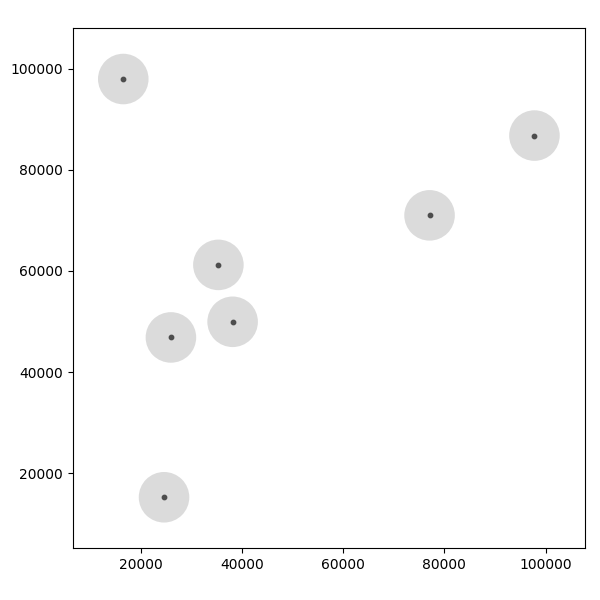

In [36]:
for year in thinned['year'].unique():
    plot_sp(df=thinned[thinned['year'] == year], coords='c', sp_threshold=spt)

#### Temporal

In [37]:
thinned = thinst(
    df=samples,
    datetimes='d',
    tm_threshold=tmt,
    tm_unit='day',
    block='year')

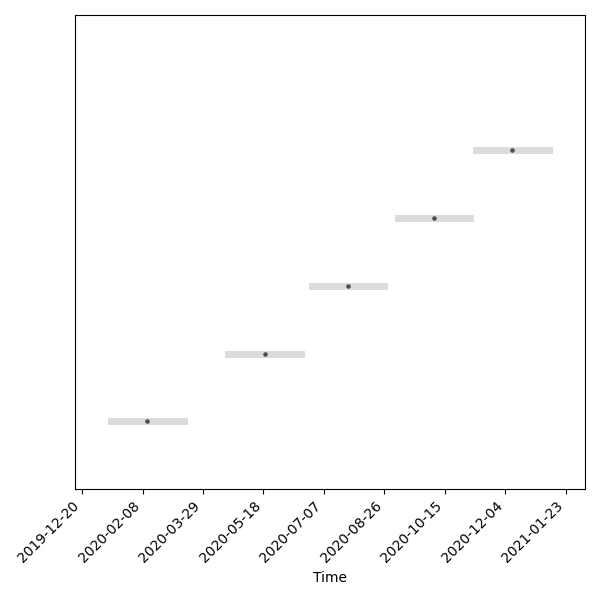

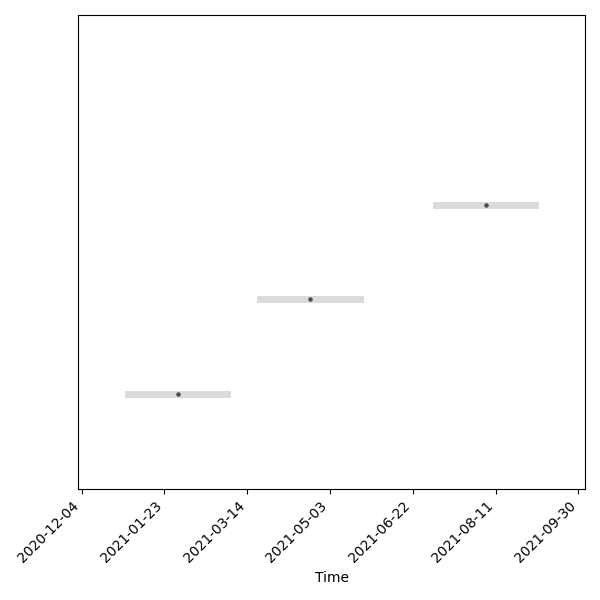

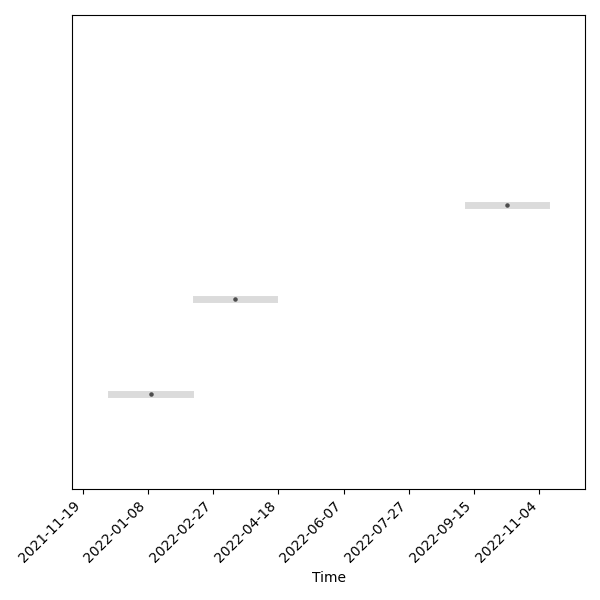

In [38]:
for year in thinned['year'].unique():
    plot_tm(df=thinned[thinned['year'] == year], datetimes='d', tm_threshold=tmt, tm_unit=tmu)

#### Spatiotemporal

In [39]:
thinned = thinst(
    df=samples,
    coords='c',
    sp_threshold=spt,
    datetimes='d',
    tm_threshold=tmt,
    tm_unit='day',
    block='year')

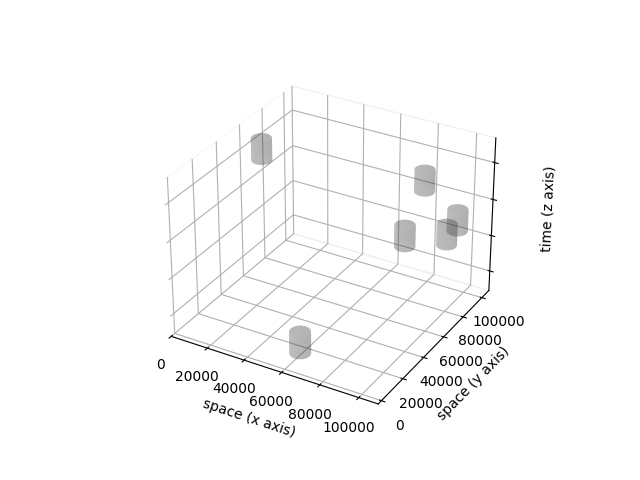

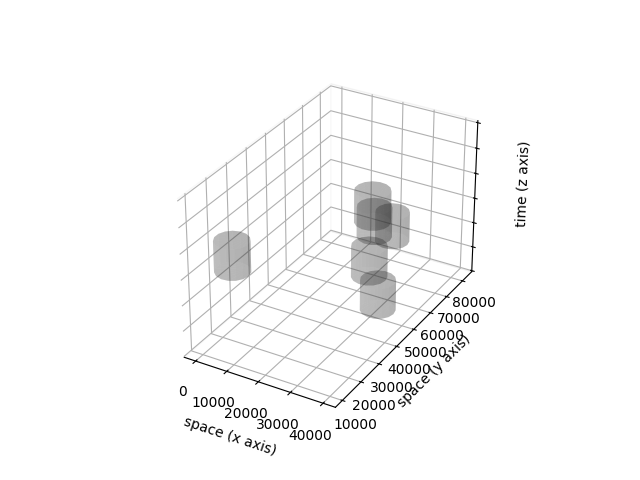

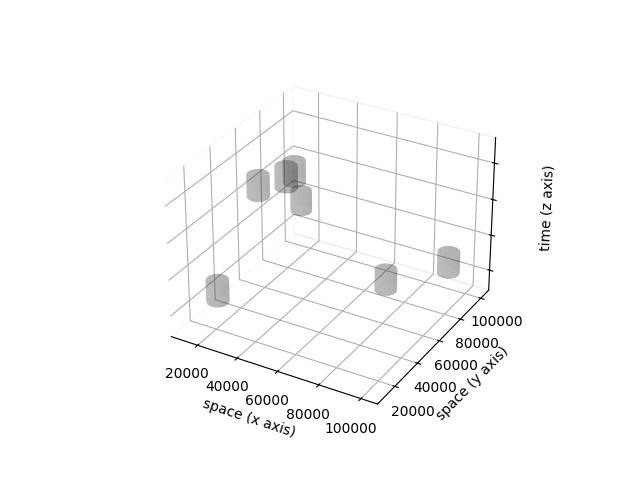

In [40]:
for year in thinned['year'].unique():
    plot_sptm(df=thinned[thinned['year'] == year], coords='c', sp_threshold=spt, datetimes='d', tm_threshold=tmt, tm_unit=tmu)